# QKeras training + hls4ml conversion workflow

Cleaned version: train the QKeras model, convert it to hls4ml for the RFSoC 4x2 part, compile the C simulation with MSYS2 on Windows, and compare Keras vs HLS predictions.

In [14]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import keras
import matplotlib.pyplot as plt

from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import accuracy_score
from qkeras.qlayers import QDense
from qkeras.quantizers import ternary
from pathlib import Path

print("Keras version:", keras.__version__)

Keras version: 2.15.0


## Load data

In [15]:
base = Path('.')

#Train on given paper training set and test on generated test set
X_train = np.load(base / '0528_X_train_0_770.npy')
y_train = np.load(base / '0528_y_train_0_770.npy')
X_test = np.load(base / 'X_2.npy')
y_test = np.load(base / 'y_2.npy')

# X_train = np.load(base / 'X_2.npy')
# y_train = np.load(base / 'y_2.npy')
# X_test = np.load(base / '0528_X_train_0_770.npy')
# y_test = np.load(base / '0528_y_train_0_770.npy')

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# X_test = X_test.reshape(X_test.shape[0], -1)

start = 0
size = 10000
end = start + size

X_train = X_train[start:end]
y_train = y_train[start:end]
X_test = X_test[start:end]
y_test = y_test[start:end]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (900000, 1540)
y_train shape: (900000,)
X_test shape: (500000, 1540)
y_test shape: (500000,)
X_train shape: (10000, 1540)
y_train shape: (10000,)
X_test shape: (10000, 1540)
y_test shape: (10000,)


## Preprocess data

The hls4ml model will expect the same normalized input values as the Keras model.

In [16]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("mean:", mean)
print("std:", std)

mean: 57.656876
std: 842.9929


## Build QKeras model

In [17]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],), name="input_1"),

    QDense(
        64,
        kernel_quantizer=ternary(),
        bias_quantizer=ternary(),
        name="q_dense_1"
    ),
    BatchNormalization(name="batchnorm1"),
    keras.layers.Activation("relu", name="relu1"),

    QDense(
        32,
        kernel_quantizer=ternary(),
        bias_quantizer=ternary(),
        name="q_dense_2"
    ),
    BatchNormalization(name="batchnorm2"),
    keras.layers.Activation("relu", name="relu2"),

    QDense(
        1,
        kernel_quantizer=ternary(),
        bias_quantizer=ternary(),
        name="q_output"
    ),
    keras.layers.Activation("sigmoid", name="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 q_dense_1 (QDense)          (None, 64)                98624     
                                                                 
 batchnorm1 (BatchNormaliza  (None, 64)                256       
 tion)                                                           
                                                                 
 relu1 (Activation)          (None, 64)                0         
                                                                 
 q_dense_2 (QDense)          (None, 32)                2080      
                                                                 
 batchnorm2 (BatchNormaliza  (None, 32)                128       
 tion)                                                           
                                                                 
 relu2 (Activation)          (None, 32)               

## Train model

In [18]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
250/250 [==============================] - 3s 6ms/step - loss: 0.2513 - accuracy: 0.9335 - val_loss: 0.2848 - val_accuracy: 0.9285
Epoch 2/50
250/250 [==============================] - 1s 4ms/step - loss: 0.1360 - accuracy: 0.9647 - val_loss: 0.2747 - val_accuracy: 0.9280
Epoch 3/50
250/250 [==============================] - 1s 4ms/step - loss: 0.0933 - accuracy: 0.9712 - val_loss: 0.3654 - val_accuracy: 0.9165
Epoch 4/50
250/250 [==============================] - 1s 3ms/step - loss: 0.0707 - accuracy: 0.9770 - val_loss: 0.2993 - val_accuracy: 0.9250
Epoch 5/50
250/250 [==============================] - 1s 4ms/step - loss: 0.0448 - accuracy: 0.9859 - val_loss: 0.3674 - val_accuracy: 0.9225
Epoch 6/50
250/250 [==============================] - 1s 4ms/step - loss: 0.0434 - accuracy: 0.9858 - val_loss: 0.3887 - val_accuracy: 0.9245
Epoch 7/50
250/250 [==============================] - 1s 4ms/step - loss: 0.0372 - accuracy: 0.9874 - val_loss: 0.4104 - val_accuracy: 0.9220
Epoch 

## Training plots

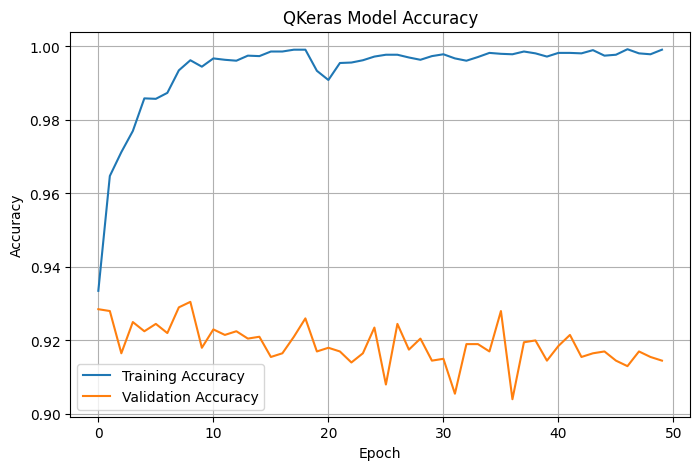

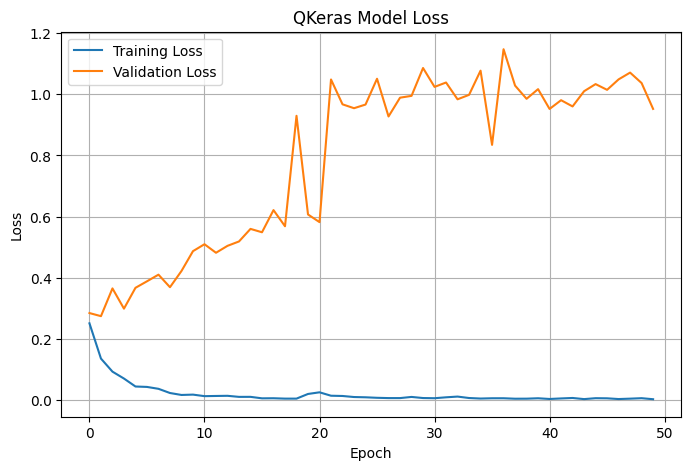

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("QKeras Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("QKeras Model Loss")
plt.legend()
plt.grid(True)
plt.show()

## hls4ml setup

In [20]:
import hls4ml

FPGA_PART = "xczu48dr-ffvg1517-2-e"  # RFSoC 4x2 FPGA part
CLOCK_PERIOD_NS = 10.0

print("hls4ml version:", hls4ml.__version__)
print("Target FPGA part:", FPGA_PART)

hls4ml version: 1.3.0
Target FPGA part: xczu48dr-ffvg1517-2-e


## Create hls4ml config

In [21]:
hls_config = hls4ml.utils.config_from_keras_model(model, granularity="name")

hls_config["Model"]["Precision"] = "ap_fixed<16,6>"
hls_config["Model"]["ReuseFactor"] = 1
hls_config["Model"]["Strategy"] = "Resource"

print("Layers hls4ml sees:")
for layer_name in hls_config["LayerName"]:
    print(" -", layer_name)


def ensure_precision_dict(layer_cfg):
    if "Precision" not in layer_cfg or not isinstance(layer_cfg["Precision"], dict):
        layer_cfg["Precision"] = {}
    return layer_cfg["Precision"]


def set_result_precision(layer_name, precision):
    if layer_name in hls_config["LayerName"]:
        precision_cfg = ensure_precision_dict(hls_config["LayerName"][layer_name])
        precision_cfg["result"] = precision
        hls_config["LayerName"][layer_name]["Trace"] = True


def set_accum_precision(layer_name, precision):
    if layer_name in hls_config["LayerName"]:
        hls_config["LayerName"][layer_name]["accum_t"] = precision


# Input is normalized floating-point data from Python, so use signed fixed-point with some integer headroom.
for possible_input_name in ["input_1", "input_1_input", "q_dense_1_input"]:
    if possible_input_name in hls_config["LayerName"]:
        hls_config["LayerName"][possible_input_name]["Precision"] = "ap_fixed<16,6>"

# Wider accumulators help preserve accuracy.
set_result_precision("q_dense_1", "ap_fixed<24,10>")
set_accum_precision("q_dense_1", "ap_fixed<24,10>")
set_result_precision("q_dense_2", "ap_fixed<24,10>")
set_accum_precision("q_dense_2", "ap_fixed<24,10>")
set_result_precision("q_output", "ap_fixed<24,10>")
set_accum_precision("q_output", "ap_fixed<24,10>")

for layer_name in ["batchnorm1", "batchnorm2", "relu1", "relu2", "sigmoid"]:
    set_result_precision(layer_name, "ap_fixed<18,8>")

for layer_name in list(hls_config["LayerName"].keys()):
    if "alpha" in layer_name or "linear" in layer_name:
        set_result_precision(layer_name, "ap_fixed<24,10>")

from pprint import pprint
pprint(hls_config, sort_dicts=False)

Layers hls4ml sees:
 - input_1
 - q_dense_1
 - q_dense_1_linear
 - batchnorm1
 - relu1
 - q_dense_2
 - q_dense_2_linear
 - batchnorm2
 - relu2
 - q_output
 - q_output_linear
 - sigmoid
{'Model': {'Precision': 'ap_fixed<16,6>',
           'ReuseFactor': 1,
           'Strategy': 'Resource',
           'BramFactor': 1000000000,
           'TraceOutput': False},
 'LayerName': {'input_1': {'Trace': False, 'Precision': 'ap_fixed<16,6>'},
               'q_dense_1': {'Trace': True,
                             'Precision': {'result': 'ap_fixed<24,10>',
                                           'weight': 'int<2>',
                                           'bias': 'int<2>'},
                             'accum_t': 'ap_fixed<24,10>'},
               'q_dense_1_linear': {'Trace': True,
                                    'Precision': {'result': 'ap_fixed<24,10>'}},
               'batchnorm1': {'Trace': True,
                              'Precision': {'result': 'ap_fixed<18,8>',
             

c:\Users\zachs\anaconda3\envs\hls4ml_env\lib\site-packages\keras\src\constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.ternary'>, which may lead to improper serialization.
  warnings.warn(


## Convert model

Always use a fresh timestamped output folder on Windows. Reusing the same hls4ml output folder can cause permission errors.

In [22]:
from pathlib import Path
from datetime import datetime

BASE_DIR = Path(r"C:\hls4ml_projects")
BASE_DIR.mkdir(exist_ok=True)

PROJECT_DIR = BASE_DIR / f"hls4ml_qubit_prj_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
print("Using output_dir:", PROJECT_DIR)

hls_model = hls4ml.converters.convert_from_keras_model(
    model=model,
    hls_config=hls_config,
    output_dir=str(PROJECT_DIR),
    part=FPGA_PART,
    io_type="io_parallel",
    clock_period=CLOCK_PERIOD_NS,
    backend="Vivado",
    project_name="NN"
)

print("hls_model output_dir:", hls_model.config.get_output_dir())

Using output_dir: C:\hls4ml_projects\hls4ml_qubit_prj_20260701_151837
hls_model output_dir: C:\hls4ml_projects\hls4ml_qubit_prj_20260701_151837


c:\Users\zachs\anaconda3\envs\hls4ml_env\lib\site-packages\hls4ml\model\graph.py:483: UserWarning: Overriding attribute 'accum_t' of layer 'q_dense_1' (Dense):<hls4ml.model.types.NamedType object at 0x000001F3164F7D00> -> <hls4ml.model.types.NamedType object at 0x000001F3164F5E10>
  self.graph[name] = self.make_node(kind, name, layer, inputs, outputs)
c:\Users\zachs\anaconda3\envs\hls4ml_env\lib\site-packages\hls4ml\model\graph.py:483: UserWarning: Overriding attribute 'accum_t' of layer 'q_dense_2' (Dense):<hls4ml.model.types.NamedType object at 0x000001F3164F76D0> -> <hls4ml.model.types.NamedType object at 0x000001F3164F74F0>
  self.graph[name] = self.make_node(kind, name, layer, inputs, outputs)
c:\Users\zachs\anaconda3\envs\hls4ml_env\lib\site-packages\hls4ml\model\graph.py:483: UserWarning: Overriding attribute 'accum_t' of layer 'q_output' (Dense):<hls4ml.model.types.NamedType object at 0x000001F3164F6C80> -> <hls4ml.model.types.NamedType object at 0x000001F3164F6950>
  self.grap

## Windows/MSYS2 compile patch

Run this before `hls_model.compile()` when using native Windows. It forces hls4ml to run `build_lib.sh` through MSYS2 Bash and adds the MSYS2 runtime DLL folders.

In [23]:
import os
import subprocess
from hls4ml.backends.fpga.fpga_backend import FPGABackend

MSYS2_BASH = r"C:\msys64\usr\bin\bash.exe"

if not os.path.exists(MSYS2_BASH):
    raise FileNotFoundError(f"Could not find MSYS2 Bash at {MSYS2_BASH}")

for dll_dir in [r"C:\msys64\ucrt64\bin", r"C:\msys64\usr\bin"]:
    if os.path.isdir(dll_dir):
        os.add_dll_directory(dll_dir)
        print("Added DLL directory:", dll_dir)
    else:
        print("Missing DLL directory:", dll_dir)


def compile_with_msys2_bash(self, model):
    output_dir = model.config.get_output_dir()
    project_name = model.config.get_project_name()
    stamp = model.config.get_config_value("Stamp")

    print("Output dir:", output_dir)
    print("Project name:", project_name)

    command = """
    export PATH=/ucrt64/bin:/usr/bin:$PATH
    echo "PWD:"
    pwd
    echo ""
    echo "Checking tools:"
    which bash
    which g++
    which make
    g++ --version
    make --version
    echo ""
    echo "Project files:"
    ls -la
    echo ""
    echo "Running build_lib.sh:"
    sed -i 's/\r$//' build_lib.sh
    chmod +x build_lib.sh
    bash -x ./build_lib.sh
    """

    ret_val = subprocess.run(
        [MSYS2_BASH, "-c", command],
        cwd=output_dir,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    print(ret_val.stdout)
    print("Return code:", ret_val.returncode)

    log_path = os.path.join(output_dir, "compile_debug.log")
    with open(log_path, "w", encoding="utf-8", errors="ignore") as f:
        f.write(ret_val.stdout)
    print("Saved compile log to:", log_path)

    if ret_val.returncode != 0:
        raise Exception(f'Failed to compile project "{project_name}" with MSYS2 Bash. Check compile_debug.log.')

    return os.path.join(output_dir, "firmware", f"{project_name}-{stamp}.so")


FPGABackend.compile = compile_with_msys2_bash
hls_model._top_function_lib = None

print("Patched hls4ml compile() to use MSYS2 Bash:", MSYS2_BASH)

Added DLL directory: C:\msys64\ucrt64\bin
Added DLL directory: C:\msys64\usr\bin
Patched hls4ml compile() to use MSYS2 Bash: C:\msys64\usr\bin\bash.exe


## Compile HLS C simulation and compare predictions

In [24]:
# Avoid hls4ml Windows dlclose issue if the cell is rerun.
hls_model._top_function_lib = None

hls_model.compile()
y_keras_prob = model.predict(X_test).reshape(-1)
X_hls = np.ascontiguousarray(X_test.astype(np.float32))
y_hls_prob = hls_model.predict(X_hls).reshape(-1)
y_keras_class = (y_keras_prob > 0.5).astype(int)
y_hls_class = (y_hls_prob > 0.5).astype(int)
y_true = y_test.astype(int).reshape(-1)
keras_acc = accuracy_score(y_true, y_keras_class)
hls_acc = accuracy_score(y_true, y_hls_class)
keras_hls_agreement = accuracy_score(y_keras_class, y_hls_class)

print("Keras accuracy:      {:.3f}%".format(keras_acc * 100))
print("hls4ml accuracy:     {:.3f}%".format(hls_acc * 100))
print("Keras/HLS agreement: {:.3f}%".format(keras_hls_agreement * 100))
print("Max abs output diff:", np.max(np.abs(y_keras_prob - y_hls_prob)))
print("Mean abs output diff:", np.mean(np.abs(y_keras_prob - y_hls_prob)))

Output dir: C:\hls4ml_projects\hls4ml_qubit_prj_20260701_151837
Project name: NN
PWD:
/c/hls4ml_projects/hls4ml_qubit_prj_20260701_151837

Checking tools:
/usr/bin/bash
/ucrt64/bin/g++
/usr/bin/make
g++.exe (Rev5, Built by MSYS2 project) 16.1.0
Copyright (C) 2026 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

GNU Make 4.4.1
Built for x86_64-pc-cygwin
Copyright (C) 1988-2023 Free Software Foundation, Inc.
License GPLv3+: GNU GPL version 3 or later <https://gnu.org/licenses/gpl.html>
This is free software: you are free to change and redistribute it.
There is NO WARRANTY, to the extent permitted by law.

Project files:
total 1302
drwxr-xr-x 1 zachs zachs       0 Jul  1 15:18 .
drwxr-xr-x 1 zachs zachs       0 Jul  1 15:18 ..
-rw-r--r-- 1 zachs zachs    2098 Jul  1 15:18 NN_bridge.cpp
-rw-r--r-- 1 zachs zachs    3732 Jul  1 15:18 NN_test.cpp
-rwxr-xr-x 1 z

## Fidelity check

In [25]:
def state_accuracies_and_fidelity(y_true, y_class):
    y_true = y_true.astype(int).reshape(-1)
    y_class = y_class.astype(int).reshape(-1)

    g_idx = np.where(y_true == 0)[0]
    e_idx = np.where(y_true == 1)[0]

    g_acc = accuracy_score(y_true[g_idx], y_class[g_idx]) if len(g_idx) else np.nan
    e_acc = accuracy_score(y_true[e_idx], y_class[e_idx]) if len(e_idx) else np.nan
    fidelity = 0.5 * (g_acc + e_acc)
    return g_acc, e_acc, fidelity

keras_g_acc, keras_e_acc, keras_fidelity = state_accuracies_and_fidelity(y_true, y_keras_class)
hls_g_acc, hls_e_acc, hls_fidelity = state_accuracies_and_fidelity(y_true, y_hls_class)

print("Keras ground accuracy:  {:.3f}%".format(keras_g_acc * 100))
print("Keras excited accuracy: {:.3f}%".format(keras_e_acc * 100))
print("Keras fidelity:         {:.3f}%".format(keras_fidelity * 100))
print()
print("HLS ground accuracy:    {:.3f}%".format(hls_g_acc * 100))
print("HLS excited accuracy:   {:.3f}%".format(hls_e_acc * 100))
print("HLS fidelity:           {:.3f}%".format(hls_fidelity * 100))

Keras ground accuracy:  100.000%
Keras excited accuracy: 100.000%
Keras fidelity:         100.000%

HLS ground accuracy:    100.000%
HLS excited accuracy:   100.000%
HLS fidelity:           100.000%


## HLS synthesis

Run this once connected to Vivado with HLS on PATH

In [26]:
# Uncomment only after Vivado/Vitis HLS is on PATH.
hls_model.build(
    csim=False,
    synth=True,
    cosim=False,
    export=True,
    vsynth=False,
)

hls4ml.report.read_vivado_report(hls_model.config.get_output_dir())

Project NN_prj does not exist. Rerun "hls4ml build -p C:\hls4ml_projects\hls4ml_qubit_prj_20260701_151837".
Project NN_prj does not exist. Rerun "hls4ml build -p C:\hls4ml_projects\hls4ml_qubit_prj_20260701_151837".
